In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
from scipy.stats import ttest_ind, chi2_contingency
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows의 경우)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [11]:
df = pd.read_csv('../data/train_raw.csv')
df.head()

# 만족도 label 인코딩
df['label'] = df['satisfaction'].map({
    'neutral or dissatisfied': 0,
    'satisfied': 1
})


비교 분석 결과
                    Count (N)  Satisfaction (%)  Business Class (%)  \
A: Arrival Delayed    11093.0              40.7                46.5   
B: Recovered          10700.0              48.8                50.6   
Diff (B - A)           -393.0               8.1                 4.1   

                    Avg Distance (mi)  Avg Delay (min)  
A: Arrival Delayed             1189.6              9.7  
B: Recovered                   1318.0              5.9  
Diff (B - A)                    128.4             -3.9  


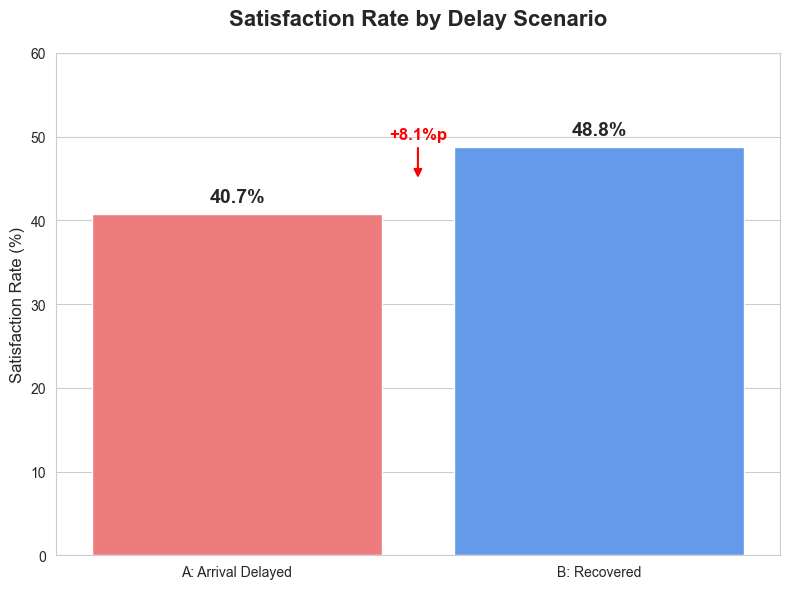

In [13]:
# ---------------------------------------------------------
# 1. 데이터 가공 및 통계 요약
# ---------------------------------------------------------

# 그룹 설정 
group_A = df[(df['Departure Delay in Minutes'] == 0) & (df['Arrival Delay in Minutes'] > 0)]
group_B = df[(df['Departure Delay in Minutes'] > 0) & (df['Arrival Delay in Minutes'] == 0)]

# 핵심 지표 계산 함수
def get_summary(group, name, delay_col):
    return {
        'Group': name,
        'Count (N)': len(group),
        'Satisfaction (%)': (group['satisfaction'] == 'satisfied').mean() * 100,
        'Business Class (%)': (group['Class'] == 'Business').mean() * 100,
        'Avg Distance (mi)': group['Flight Distance'].mean(),
        'Avg Delay (min)': group[delay_col].mean()
    }

# 데이터 프레임 생성
summary_list = [
    get_summary(group_A, "A: Arrival Delayed", 'Arrival Delay in Minutes'),
    get_summary(group_B, "B: Recovered", 'Departure Delay in Minutes')
]

summary_df = pd.DataFrame(summary_list).set_index('Group')

# 차이(Diff) 행 추가 (B - A)
diff_row = summary_df.iloc[1] - summary_df.iloc[0]
diff_row.name = "Diff (B - A)"
summary_df_print = pd.concat([summary_df, diff_row.to_frame().T])

# 결과 텍스트 출력
print("="*60)
print("비교 분석 결과")
print("="*60)
print(summary_df_print.round(1))
print("="*60)

# ---------------------------------------------------------
# 2. 만족도 시각화 (Visualization)
# ---------------------------------------------------------

# 그래프 스타일 설정
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

# 색상 지정: A그룹(부정적 상황)은 붉은 계열, B그룹(긍정적 상황)은 푸른 계열
colors = ['#FF6B6B', '#4D96FF'] # 파스텔 레드, 파스텔 블루

# 바 차트 그리기
ax = sns.barplot(x=summary_df.index, y=summary_df['Satisfaction (%)'], palette=colors)

# 바 위에 수치 표시 (Annotation)
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 1, # 위치 조절
            f'{height:.1f}%', 
            ha="center", va="bottom", fontsize=14, fontweight='bold')

# 차이(Diff) 화살표 및 텍스트 추가 (선택 사항)
diff_val = summary_df.iloc[1]['Satisfaction (%)'] - summary_df.iloc[0]['Satisfaction (%)']
mid_h = (summary_df.iloc[0]['Satisfaction (%)'] + summary_df.iloc[1]['Satisfaction (%)']) / 2
plt.annotate(f'+{diff_val:.1f}%p', 
             xy=(0.5, mid_h), 
             xytext=(0.5, mid_h + 5),
             ha='center', fontsize=12, color='red', fontweight='bold',
             arrowprops=dict(arrowstyle='-|>', color='red', lw=1.5))

# 레이블 및 타이틀 설정
plt.title('Satisfaction Rate by Delay Scenario', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Satisfaction Rate (%)', fontsize=12)
plt.xlabel('')
plt.ylim(0, 60) # Y축 범위 넉넉하게 설정

plt.tight_layout()
plt.show()

In [14]:

# 통계 검정 통합 함수
def analyze_homogeneity(df_a, df_b, continuous_cols, categorical_cols):
    """
    두 그룹 간의 동질성 검정 (Continuous: Mann-Whitney / Categorical: Chi-square)
    결과: P-value 및 Effect Size가 포함된 DataFrame 리턴
    """
    results = []
    
    # 2-1. 연속형 변수 분석 (Mann-Whitney U Test)
    for col in continuous_cols:
        # 검정 수행
        stat, p_val = stats.mannwhitneyu(df_a[col], df_b[col], alternative='two-sided')
        
        # 효과 크기 계산 (Rank-Biserial Correlation)
        n1, n2 = len(df_a), len(df_b)
        effect_size = 1 - (2 * stat) / (n1 * n2)
        
        results.append({
            'Variable': col,
            'Type': 'Continuous',
            'Test': 'Mann-Whitney U',
            'P-value': p_val,
            'Effect Size': abs(effect_size), # 절대값 처리
            'Metric': 'Rank-Biserial',
            'Interpretation': '무시 가능' if abs(effect_size) < 0.1 else ('작음' if abs(effect_size) < 0.3 else '주의')
        })

    # 2-2. 범주형 변수 분석 (Chi-squared Test)
    for col in categorical_cols:
        # 데이터 병합 후 교차표 생성
        combined = pd.concat([df_a[[col]].assign(group='A'), df_b[[col]].assign(group='B')])
        contingency = pd.crosstab(combined['group'], combined[col])
        
        # 검정 수행
        chi2, p_val, dof, _ = stats.chi2_contingency(contingency)
        
        # 효과 크기 계산 (Cramér's V)
        n = contingency.sum().sum()
        min_dim = min(contingency.shape) - 1
        cramers_v = np.sqrt(chi2 / (n * min_dim))
        
        results.append({
            'Variable': col,
            'Type': 'Categorical',
            'Test': 'Chi-squared',
            'P-value': p_val,
            'Effect Size': cramers_v,
            'Metric': "Cramér's V",
            'Interpretation': '무시 가능' if cramers_v < 0.1 else ('작음' if cramers_v < 0.3 else '주의')
        })
        
    return pd.DataFrame(results)

# 데이터 준비 및 실행
# 그룹 설정 (이미 되어 있다고 가정)
group_A = df[(df['Departure Delay in Minutes'] == 0) & (df['Arrival Delay in Minutes'] > 0)]
group_B = df[(df['Departure Delay in Minutes'] > 0) & (df['Arrival Delay in Minutes'] == 0)]

# 분석할 변수 지정
cont_vars = ['Flight Distance'] # 지연 시간은 '차이'가 명확하므로 환경 변수 비교에선 제외하거나 별도 언급
cat_vars = ['Class', 'Inflight service', 'Cleanliness', 'Food and drink', 'Seat comfort'] # 서비스 변수들

# 함수 실행
stat_result = analyze_homogeneity(group_A, group_B, cont_vars, cat_vars)

print("="*60)
print("📊 두 그룹 간 환경 동질성 검정 결과 (Effect Size 중심)")
print("="*60)
# 보기 좋게 출력
display_cols = ['Variable', 'Type', 'P-value', 'Effect Size', 'Interpretation']
print(stat_result[display_cols].round(4))
print("="*60)

📊 두 그룹 간 환경 동질성 검정 결과 (Effect Size 중심)
           Variable         Type  P-value  Effect Size Interpretation
0   Flight Distance   Continuous      0.0       0.1036             작음
1             Class  Categorical      0.0       0.0426          무시 가능
2  Inflight service  Categorical      0.0       0.0648          무시 가능
3       Cleanliness  Categorical      0.0       0.0428          무시 가능
4    Food and drink  Categorical      0.0       0.0363          무시 가능
5      Seat comfort  Categorical      0.0       0.0522          무시 가능


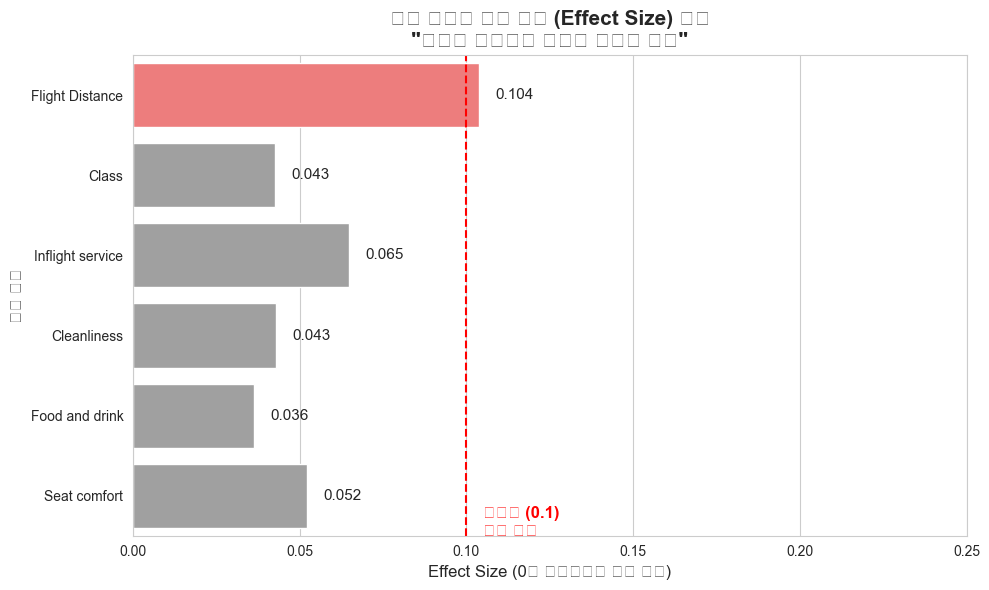

In [15]:
# ----------------------------------------------------------
# 시각화 1: 효과 크기 (Effect Size) 비교 차트
# ----------------------------------------------------------
def plot_effect_sizes(result_df):
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    # 색상 설정: 무시 가능(회색), 주의(빨강)
    colors = result_df['Effect Size'].apply(lambda x: '#A0A0A0' if x < 0.1 else '#FF6B6B').tolist()
    
    # 바 차트
    ax = sns.barplot(
        data=result_df, 
        x='Effect Size', 
        y='Variable', 
        palette=colors
    )
    
    # 기준선 (0.1: 무시 가능 한계선)
    plt.axvline(x=0.1, color='red', linestyle='--', linewidth=1.5)
    plt.text(0.105, len(result_df)-0.5, '기준선 (0.1)\n무시 가능', color='red', fontsize=12, fontweight='bold')
    
    # 수치 텍스트 추가
    for i, p in enumerate(ax.patches):
        width = p.get_width()
        ax.text(width + 0.005, p.get_y() + p.get_height()/2, 
                f'{width:.3f}', 
                va='center', fontsize=11)
        
    plt.title('환경 변수별 효과 크기 (Effect Size) 분석\n"수치는 존재하나 실질적 차이는 없음"', fontsize=15, fontweight='bold')
    plt.xlabel('Effect Size (0에 가까울수록 차이 없음)', fontsize=12)
    plt.ylabel('비교 변수', fontsize=12)
    plt.xlim(0, 0.25) # 범위 조절 (필요시 변경)
    
    plt.tight_layout()
    plt.show()

# 실행
plot_effect_sizes(stat_result)

Service Score Comparison (Chi-squared Test & Cramer's V)

Class Distribution Comparison (Chi-square Test)
Group A Business 비율: 46.5%
Group B Business 비율: 50.6%
차이: 4.1%p

Chi-square: 0.18
P-value: 0.913378
Cramér's V: 0.0063 → 무시 가능 ✓

All Variables Summary (Sorted by Effect Size)
Variable                       Mean_A   Mean_B   P-value    Cramer V   Interp
-------------------------------------------------------------------------------------
Inflight service                  3.61    3.75    0.0000     0.065 Negligible
On-board service                  3.34    3.49    0.0000     0.059 Negligible
Baggage handling                  3.60    3.72    0.0000     0.054 Negligible
Checkin service                   3.27    3.39    0.0000     0.053 Negligible
Seat comfort                      3.41    3.53    0.0000     0.052 Negligible
Inflight entertainment            3.32    3.44    0.0000     0.048 Negligible
Online boarding                   3.22    3.32    0.0000     0.048 Negligible
Leg room

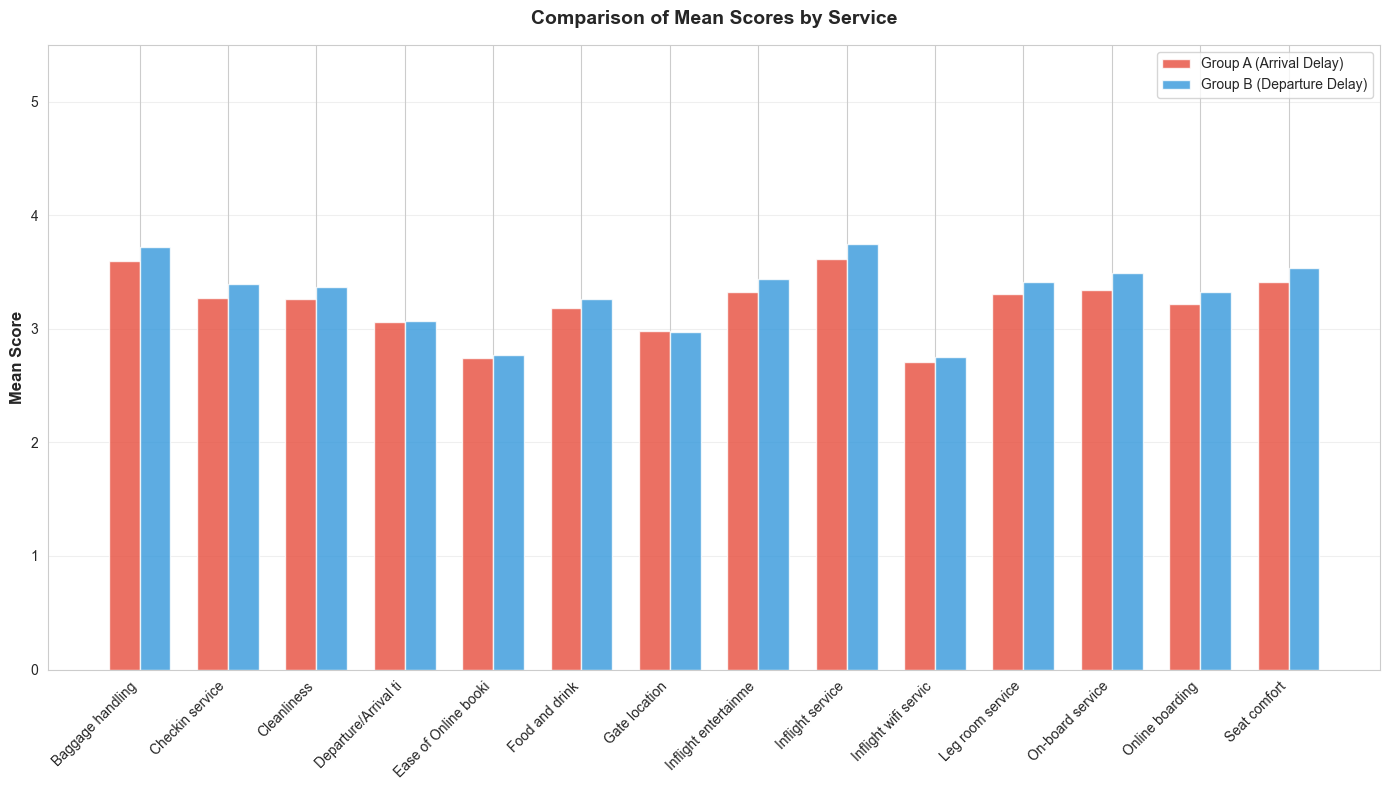

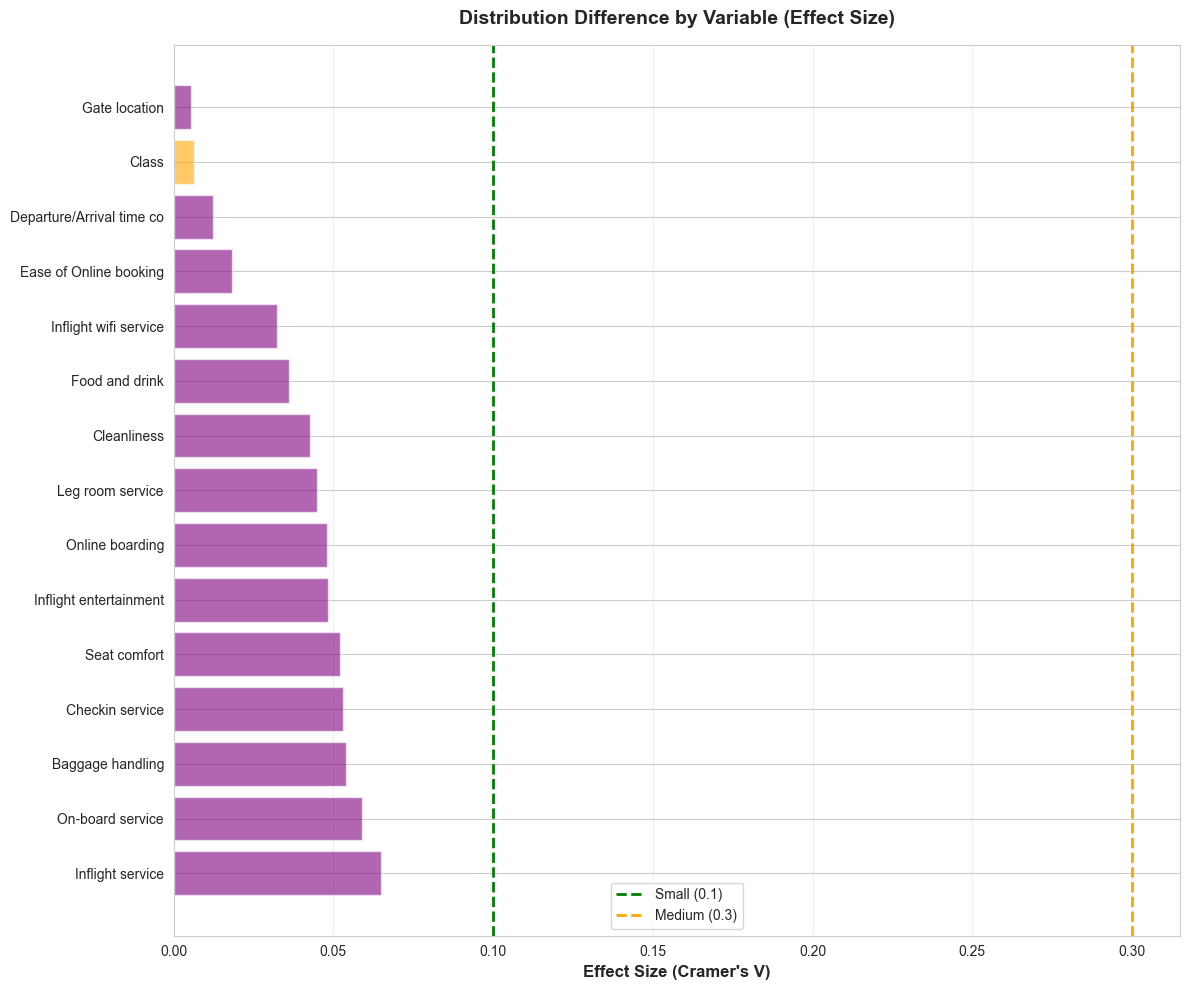

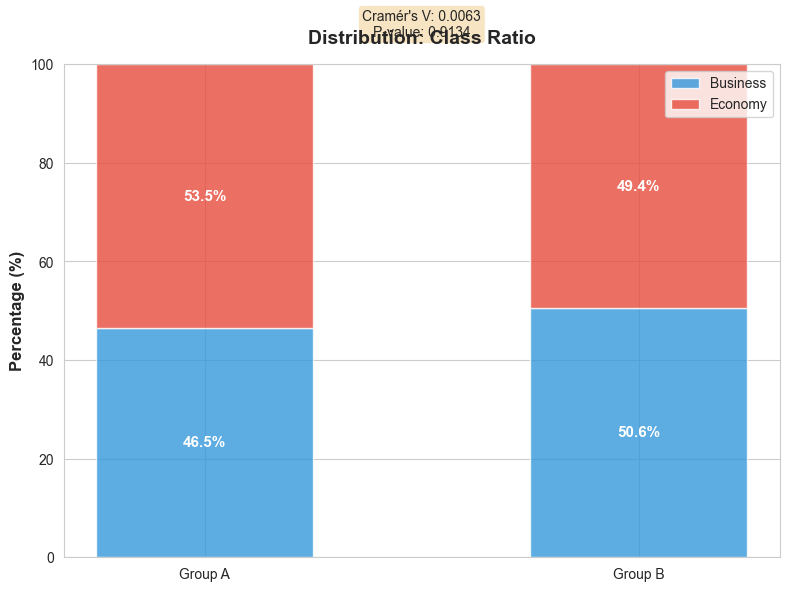


CONCLUSION
Average Effect Size (Cramer's V) across all services: 0.0408
✅ Service score distribution difference: Negligible

Class distribution difference: 0.0063 → 무시 가능 ✓


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# ============================================================
# 1. Service Score & Class Comparison (Chi-squared Test)
# ============================================================
# Service columns list
service_columns = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

print("="*80)
print("Service Score Comparison (Chi-squared Test & Cramer's V)")
print("="*80)

results = []

for service in service_columns:
    # 1. Create Contingency Table
    temp_A = group_A[[service]].copy()
    temp_A['Group'] = 'A'
    temp_B = group_B[[service]].copy()
    temp_B['Group'] = 'B'
    
    combined = pd.concat([temp_A, temp_B])
    
    # Cross tabulation (Rows: Score, Cols: Group)
    cross_tab = pd.crosstab(combined[service], combined['Group'])
    
    # 2. Chi-squared Test
    chi2, p_value, dof, expected = chi2_contingency(cross_tab)
    
    # 3. Effect Size (Cramer's V)
    n = cross_tab.sum().sum()
    min_dim = min(cross_tab.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    
    # 4. Simple Mean (For reference only)
    mean_A = group_A[service].mean()
    mean_B = group_B[service].mean()
    diff = mean_B - mean_A
    
    results.append({
        'Service': service,
        'Mean_A': mean_A,
        'Mean_B': mean_B,
        'Diff': diff,
        'P-value': p_value,
        'Cramers_V': cramers_v
    })

# ============================================================
# 2. Class Comparison (추가)
# ============================================================
print("\n" + "="*80)
print("Class Distribution Comparison (Chi-square Test)")
print("="*80)

# Contingency table
contingency_class = pd.crosstab(
    pd.Series(['Group A'] * len(group_A) + ['Group B'] * len(group_B)),
    pd.concat([group_A['Class'], group_B['Class']])
)

# Chi-square test
chi2_class, p_value_class, dof_class, expected_class = chi2_contingency(contingency_class)

# Cramér's V (효과 크기)
n_class = contingency_class.sum().sum()
cramers_v_class = np.sqrt(chi2_class / (n_class * (min(contingency_class.shape) - 1)))

# Business 비율 계산
business_A = (group_A['Class'] == 'Business').mean()
business_B = (group_B['Class'] == 'Business').mean()

print(f"Group A Business 비율: {business_A:.1%}")
print(f"Group B Business 비율: {business_B:.1%}")
print(f"차이: {abs(business_A - business_B)*100:.1f}%p")
print(f"\nChi-square: {chi2_class:.2f}")
print(f"P-value: {p_value_class:.6f}")
print(f"Cramér's V: {cramers_v_class:.4f}", end=" ")

if cramers_v_class < 0.1:
    print("→ 무시 가능 ✓")
elif cramers_v_class < 0.3:
    print("→ 작음")
else:
    print("→ 고려 필요")

# Class를 결과에 추가
results.append({
    'Service': 'Class',
    'Mean_A': business_A * 100,  # Business 비율(%)
    'Mean_B': business_B * 100,
    'Diff': (business_B - business_A) * 100,
    'P-value': p_value_class,
    'Cramers_V': cramers_v_class
})

# Convert to DataFrame
result_df = pd.DataFrame(results)
result_df = result_df.sort_values('Cramers_V', ascending=False)

# ============================================================
# 3. Print Table
# ============================================================
print("\n" + "="*80)
print("All Variables Summary (Sorted by Effect Size)")
print("="*80)

print(f"{'Variable':<30} {'Mean_A':<8} {'Mean_B':<8} {'P-value':<10} {'Cramer V':<10} {'Interp'}")
print("-"*85)

for _, row in result_df.iterrows():
    var_name = row['Service'][:28]
    v = row['Cramers_V']
    
    # Interpretation of Cramer's V
    if v < 0.1:
        interpretation = "Negligible"
    elif v < 0.3:
        interpretation = "Small"
    elif v < 0.5:
        interpretation = "Medium"
    else:
        interpretation = "Large"
        
    print(f"{var_name:<30} {row['Mean_A']:>7.2f} {row['Mean_B']:>7.2f} "
          f"{row['P-value']:>9.4f} {v:>9.3f} {interpretation}")

# ============================================================
# 4. Visualization - Plot 1: Service Mean Scores
# ============================================================
# Service만 필터
service_df = result_df[result_df['Service'] != 'Class'].copy()
sorted_service = service_df.sort_values('Service')

plt.figure(figsize=(14, 8))
x = np.arange(len(service_columns))
width = 0.35

bars1 = plt.bar(x - width/2, sorted_service['Mean_A'], width, 
                label='Group A (Arrival Delay)', color='#E74C3C', alpha=0.8)
bars2 = plt.bar(x + width/2, sorted_service['Mean_B'], width, 
                label='Group B (Departure Delay)', color='#3498DB', alpha=0.8)

plt.ylabel('Mean Score', fontweight='bold', fontsize=12)
plt.title('Comparison of Mean Scores by Service', fontweight='bold', fontsize=14, pad=15)
plt.xticks(x, [s[:20] for s in sorted_service['Service']], rotation=45, ha='right')
plt.legend(fontsize=10)
plt.ylim(0, 5.5)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 5. Visualization - Plot 2: Cramer's V (Effect Size)
# ============================================================
plt.figure(figsize=(12, 10))
y_pos = np.arange(len(result_df))

# 색상 구분 (Class는 다른 색)
colors = ['orange' if row['Service'] == 'Class' else 'purple' 
          for _, row in result_df.iterrows()]

bars = plt.barh(y_pos, result_df['Cramers_V'], color=colors, alpha=0.6)

# Threshold lines
plt.axvline(x=0.1, color='green', linestyle='--', linewidth=2, label='Small (0.1)')
plt.axvline(x=0.3, color='orange', linestyle='--', linewidth=2, label='Medium (0.3)')

plt.yticks(y_pos, [s[:25] for s in result_df['Service']])
plt.xlabel("Effect Size (Cramer's V)", fontweight='bold', fontsize=12)
plt.title("Distribution Difference by Variable (Effect Size)", fontweight='bold', fontsize=14, pad=15)
plt.legend(fontsize=10)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 6. Visualization - Plot 3: Class Ratio
# ============================================================
plt.figure(figsize=(8, 6))

class_data = pd.DataFrame({
    'Group': ['Group A', 'Group A', 'Group B', 'Group B'],
    'Class': ['Business', 'Economy', 'Business', 'Economy'],
    'Percentage': [
        business_A * 100,
        (1 - business_A) * 100,
        business_B * 100,
        (1 - business_B) * 100
    ]
})

# Stacked bar chart
business_data = class_data[class_data['Class'] == 'Business']
economy_data = class_data[class_data['Class'] == 'Economy']

x_pos = [0, 1]
width = 0.5

bars1 = plt.bar(x_pos, business_data['Percentage'], width, 
                label='Business', color='#3498DB', alpha=0.8)
bars2 = plt.bar(x_pos, economy_data['Percentage'], width, 
                bottom=business_data['Percentage'].values,
                label='Economy', color='#E74C3C', alpha=0.8)

plt.title('Distribution: Class Ratio', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('')
plt.ylabel('Percentage (%)', fontweight='bold', fontsize=12)
plt.xticks(x_pos, ['Group A', 'Group B'])
plt.legend(loc='upper right', fontsize=10)
plt.ylim(0, 100)

# Add percentage labels
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    
    plt.text(bar1.get_x() + bar1.get_width()/2., height1/2,
             f'{height1:.1f}%', ha='center', va='center', 
             fontweight='bold', color='white', fontsize=11)
    
    plt.text(bar2.get_x() + bar2.get_width()/2., height1 + height2/2,
             f'{height2:.1f}%', ha='center', va='center',
             fontweight='bold', color='white', fontsize=11)

# Add effect size text
plt.text(0.5, 105, 
         f"Cramér's V: {cramers_v_class:.4f}\nP-value: {'<0.001' if p_value_class < 0.001 else f'{p_value_class:.4f}'}",
         ha='center', va='bottom', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# ============================================================
# 7. Summary
# ============================================================
avg_cramers_v = service_df['Cramers_V'].mean()

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)
print(f"Average Effect Size (Cramer's V) across all services: {avg_cramers_v:.4f}")

if avg_cramers_v < 0.1:
    print("✅ Service score distribution difference: Negligible")
else:
    print("⚠️ Service score distribution difference: Consider impact")

print(f"\nClass distribution difference: {cramers_v_class:.4f} → ", end="")
print("무시 가능 ✓" if cramers_v_class < 0.1 else "고려 필요")

Continuous Variables Comparison (Mann-Whitney U Test)
Variable             Med_A    Med_B    Mean_A   Mean_B   P-value      Effect
--------------------------------------------------------------------------------
Flight Distance        861.0  1016.5  1189.6  1318.0     < 0.001 0.1036 (작음)
Delay Time               6.0     4.0     9.7     5.9     < 0.001 0.2289 (작음)


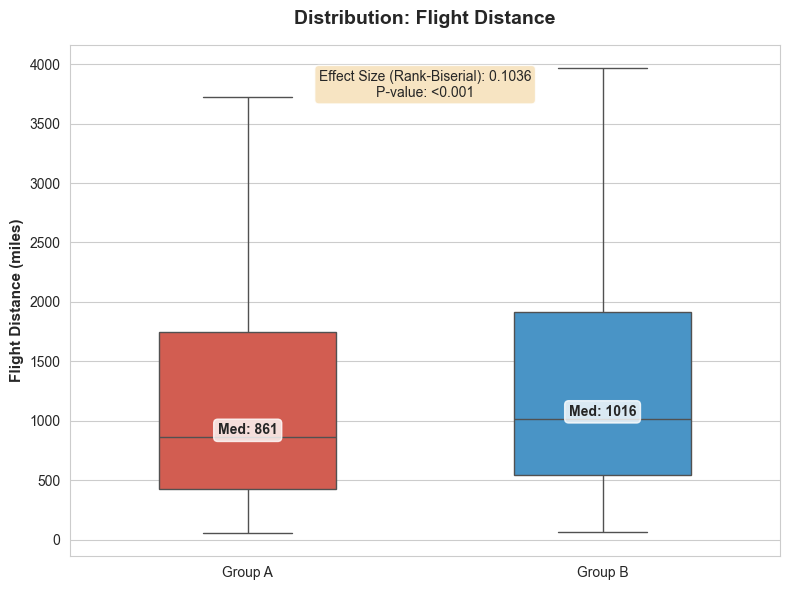

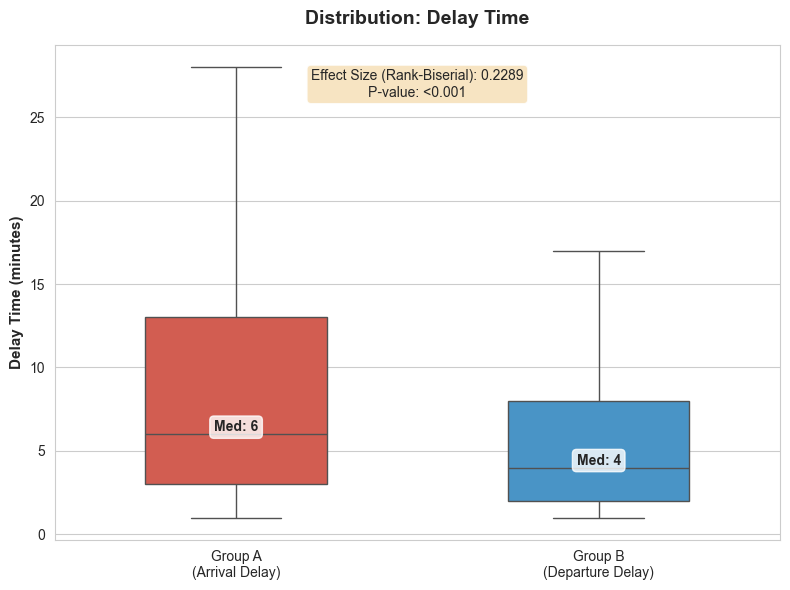


INTERPRETATION GUIDE
1. [Flight Distance]
   - Median Difference: 155.5 miles
   - Effect Size: 0.1036 → 무시 가능 ✓

2. [Delay Time]
   - Median Difference: 2.0 minutes
   - Group A (Arrival Delay): 6.0 min
   - Group B (Departure Delay): 4.0 min
   - Effect Size: 0.2289 → 작음


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# ============================================================
# 1. Continuous Variables Only
# ============================================================
# 지연 시간 비교용 데이터
delay_A = group_A['Arrival Delay in Minutes'].dropna()   # 그룹 A의 실제 지연
delay_B = group_B['Departure Delay in Minutes'].dropna()  # 그룹 B의 실제 지연

print("="*80)
print("Continuous Variables Comparison (Mann-Whitney U Test)")
print("="*80)

results_cont = []

# 1. Flight Distance
data_A_dist = group_A['Flight Distance'].dropna()
data_B_dist = group_B['Flight Distance'].dropna()

u_stat_dist, p_value_dist = mannwhitneyu(data_A_dist, data_B_dist, alternative='two-sided')

# 효과 크기 (Rank-Biserial)
n1_dist = len(data_A_dist)
n2_dist = len(data_B_dist)
rb_dist = abs(1 - (2 * u_stat_dist) / (n1_dist * n2_dist))

results_cont.append({
    'Variable': 'Flight Distance',
    'Median_A': data_A_dist.median(),
    'Median_B': data_B_dist.median(),
    'Mean_A': data_A_dist.mean(),
    'Mean_B': data_B_dist.mean(),
    'P-value': p_value_dist,
    'Effect_Size': rb_dist
})

# 2. Delay Time
u_stat_delay, p_value_delay = mannwhitneyu(delay_A, delay_B, alternative='two-sided')

n1_delay = len(delay_A)
n2_delay = len(delay_B)
rb_delay = abs(1 - (2 * u_stat_delay) / (n1_delay * n2_delay))

results_cont.append({
    'Variable': 'Delay Time',
    'Median_A': delay_A.median(),
    'Median_B': delay_B.median(),
    'Mean_A': delay_A.mean(),
    'Mean_B': delay_B.mean(),
    'P-value': p_value_delay,
    'Effect_Size': rb_delay
})

# Convert to DataFrame
df_cont_results = pd.DataFrame(results_cont)

# Print Table
print(f"{'Variable':<20} {'Med_A':<8} {'Med_B':<8} {'Mean_A':<8} {'Mean_B':<8} {'P-value':<12} {'Effect'}")
print("-"*80)

for _, row in df_cont_results.iterrows():
    p_val_str = "< 0.001" if row['P-value'] < 0.001 else f"{row['P-value']:.4f}"
    
    # Effect Size Interpretation
    es = row['Effect_Size']
    if es < 0.1:
        es_str = f"{es:.4f} (무시 가능)"
    elif es < 0.3:
        es_str = f"{es:.4f} (작음)"
    elif es < 0.5:
        es_str = f"{es:.4f} (중간)"
    else:
        es_str = f"{es:.4f} (큼)"
    
    print(f"{row['Variable']:<20} {row['Median_A']:>7.1f} {row['Median_B']:>7.1f} "
          f"{row['Mean_A']:>7.1f} {row['Mean_B']:>7.1f} {p_val_str:>11} {es_str}")

# ============================================================
# 2. Visualization - Plot 1: Flight Distance
# ============================================================
sns.set_style("whitegrid")

plot_data_dist = pd.DataFrame({
    'Flight Distance': pd.concat([data_A_dist, data_B_dist]),
    'Group': ['Group A'] * len(data_A_dist) + ['Group B'] * len(data_B_dist)
})

palette_colors = {'Group A': '#E74C3C', 'Group B': '#3498DB'}

plt.figure(figsize=(8, 6))
sns.boxplot(x='Group', y='Flight Distance', data=plot_data_dist, 
            palette=palette_colors, width=0.5, showfliers=False)

plt.title('Distribution: Flight Distance', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('')
plt.ylabel('Flight Distance (miles)', fontweight='bold', fontsize=11)

# Add median annotations
med_A_dist = data_A_dist.median()
med_B_dist = data_B_dist.median()

plt.text(0, med_A_dist, f'Med: {med_A_dist:.0f}', 
         ha='center', va='bottom', fontweight='bold', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.text(1, med_B_dist, f'Med: {med_B_dist:.0f}', 
         ha='center', va='bottom', fontweight='bold', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Add effect size text
plt.text(0.5, plt.ylim()[1] * 0.95, 
         f'Effect Size (Rank-Biserial): {rb_dist:.4f}\nP-value: {"<0.001" if p_value_dist < 0.001 else f"{p_value_dist:.4f}"}',
         ha='center', va='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# ============================================================
# 3. Visualization - Plot 2: Delay Time
# ============================================================
plot_data_delay = pd.DataFrame({
    'Delay Time': pd.concat([delay_A, delay_B]),
    'Group': ['Group A\n(Arrival Delay)'] * len(delay_A) + ['Group B\n(Departure Delay)'] * len(delay_B)
})

palette_delay = {
    'Group A\n(Arrival Delay)': '#E74C3C',
    'Group B\n(Departure Delay)': '#3498DB'
}

plt.figure(figsize=(8, 6))
sns.boxplot(x='Group', y='Delay Time', data=plot_data_delay, 
            palette=palette_delay, width=0.5, showfliers=False)

plt.title('Distribution: Delay Time', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('')
plt.ylabel('Delay Time (minutes)', fontweight='bold', fontsize=11)

# Add median annotations
med_delay_A = delay_A.median()
med_delay_B = delay_B.median()

plt.text(0, med_delay_A, f'Med: {med_delay_A:.0f}', 
         ha='center', va='bottom', fontweight='bold', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.text(1, med_delay_B, f'Med: {med_delay_B:.0f}', 
         ha='center', va='bottom', fontweight='bold', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Add effect size text
plt.text(0.5, plt.ylim()[1] * 0.95, 
         f'Effect Size (Rank-Biserial): {rb_delay:.4f}\nP-value: {"<0.001" if p_value_delay < 0.001 else f"{p_value_delay:.4f}"}',
         ha='center', va='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# ============================================================
# 4. Interpretation Summary
# ============================================================
print("\n" + "="*80)
print("INTERPRETATION GUIDE")
print("="*80)

print(f"1. [Flight Distance]")
print(f"   - Median Difference: {abs(med_A_dist - med_B_dist):.1f} miles")
print(f"   - Effect Size: {rb_dist:.4f} → {'무시 가능 ✓' if rb_dist < 0.2 else '고려 필요'}")

print(f"\n2. [Delay Time]")
print(f"   - Median Difference: {abs(med_delay_A - med_delay_B):.1f} minutes")
print(f"   - Group A (Arrival Delay): {med_delay_A:.1f} min")
print(f"   - Group B (Departure Delay): {med_delay_B:.1f} min")
print(f"   - Effect Size: {rb_delay:.4f} → {'작음' if rb_delay < 0.3 else '고려 필요'}")

In [14]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 데이터 준비
df_combined = pd.concat([
    group_A.assign(delay_type='arrival'),
    group_B.assign(delay_type='departure')
])

# 지연 시간 변수 생성
df_combined['delay_minutes'] = df_combined.apply(
    lambda x: x['Arrival Delay in Minutes'] if x['delay_type'] == 'arrival' 
              else x['Departure Delay in Minutes'],
    axis=1
)

# 독립변수
X = pd.DataFrame({
    'delay_minutes': df_combined['delay_minutes'],  # 지연 시간 통제!
    'delay_type_arrival': (df_combined['delay_type'] == 'arrival').astype(int),
    'class_business': (df_combined['Class'] == 'Business').astype(int),
    'distance': df_combined['Flight Distance'],
    'service_avg': df_combined[service_columns].mean(axis=1)
})

# 종속변수
y = (df_combined['satisfaction'] == 'satisfied').astype(int)

# 회귀분석
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# 계수 출력
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
})

print("="*80)
print("로지스틱 회귀분석 결과 (지연 시간 통제)")
print("="*80)
print(coef_df)
print("\n💡 해석:")
print("delay_type_arrival의 계수가 음수면:")
print("→ '지연 시간이 같아도' 도착 지연이 더 치명적")

로지스틱 회귀분석 결과 (지연 시간 통제)
             Variable  Coefficient
0       delay_minutes    -0.013227
1  delay_type_arrival    -0.209573
2      class_business     2.159451
3            distance     0.000172
4         service_avg     1.398291

💡 해석:
delay_type_arrival의 계수가 음수면:
→ '지연 시간이 같아도' 도착 지연이 더 치명적
